### Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scirpy as ir
import pygliph as pg

C:\Users\wwspa\miniconda3\envs\tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_tcr = pd.read_csv('./tcr_data/AGBUSCH_MOUSE_TCR_ANY_EPITOPE_single_TCRs_reactive_updated_scores.csv')
df = df_tcr[df_tcr.annotated_specificity=='OVA'].reset_index(drop = True).copy()
df.tcr_id.nunique()

14678

In [3]:
df_naive_tcr = pd.read_csv('./tcr_data/AGBUSCH_MOUSE_TCR_NAIVE_single_TCRs.csv')

Adjusted GLIPH2 workflow

Local CDR3 motif enrichment was assessed using an approach adapted from the local-convergence framework introduced in GLIPH and GLIPH2 \cite{Glanville2017,Huang2020}. Local CDR3 motif enrichment was assessed by comparing epitope-specific TCR sequences with the antigen-unselected naïve repertoire baseline. Unique full-length CDR3 amino-acid sequences were identified and terminal residues were trimmed (two N-terminal and three C-terminal residues) to reduce contributions from germline-encoded V- and J-derived sequence. All contiguous 3–5 amino-acid motifs were enumerated, and motif prevalence was calculated as the fraction of unique CDR3 sequences containing each motif. Motifs represented by at least three epitope-specific CDR3s were tested for enrichment relative to the complete naïve repertoire using a one-sided Fisher's exact test, (optional: followed by Benjamini–Hochberg correction for multiple testing). Fold enrichment was calculated from motif frequencies in the epitope-specific and naïve repertoires. To reduce redundancy among nested k-mers, motifs occurring in identical sets of epitope-specific CDR3 sequences were optionally collapsed, retaining either the shortest or longest representative motif.

In [4]:
from collections import Counter, defaultdict

def get_motifs(seq, motif_lengths=(2, 3, 4)):
    """
    Return unique continuous motifs occurring within one CDR3.
    A motif is counted at most once per TCR.
    """
    motifs = set()

    if not isinstance(seq, str):
        return motifs

    for k in motif_lengths:
        for i in range(len(seq) - k + 1):
            motifs.add(seq[i:i+k])

    return motifs

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from collections import Counter
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm


def trim_cdr3(seq, ntrim=2, ctrim=3):
    if not isinstance(seq, str):
        return None

    if len(seq) <= (ntrim + ctrim):
        return None

    end = -ctrim if ctrim > 0 else None

    return seq[ntrim:end]


def get_motifs(seq, motif_lengths=(3, 4, 5)):
    """
    Return unique contiguous k-mer motifs within one sequence.

    A motif is counted at most once per CDR3.
    """
    motifs = set()

    if not isinstance(seq, str):
        return motifs

    for k in motif_lengths:
        if len(seq) < k:
            continue

        for i in range(len(seq) - k + 1):
            motifs.add(seq[i:i+k])

    return motifs


def collapse_motif_support(
    result,
    motif_support,
    mode="longest",
):
    """
    Collapse motifs that occur in exactly the same set of
    epitope-specific CDR3 sequences.

    Parameters
    ----------
    result : pd.DataFrame
        Motif enrichment results after FDR correction.

    motif_support : dict
        motif -> frozenset of epitope CDR3 observation IDs.

    mode : {"longest", "shortest"}
        Which motif to retain when several motifs have identical support.

    Returns
    -------
    pd.DataFrame
        Collapsed motif table.
    """

    if mode not in {"longest", "shortest"}:
        raise ValueError(
            "mode must be either 'longest' or 'shortest'"
        )

    # --------------------------------------------------
    # Group motifs by identical epitope support
    # --------------------------------------------------
    support_groups = defaultdict(list)

    for motif in result["motif"]:
        support = motif_support[motif]
        support_groups[support].append(motif)

    representatives = []
    collapse_info = {}

    for support, motifs in support_groups.items():

        df_group = result[
            result["motif"].isin(motifs)
        ].copy()

        # ----------------------------------------------
        # Select representative motif
        # ----------------------------------------------
        if mode == "longest":

            df_group = df_group.sort_values(
                [
                    "length",
                    "q",
                    "fold_enrichment",
                    "motif",
                ],
                ascending=[
                    False,   # longest first
                    True,    # lowest q
                    False,   # highest enrichment
                    True,
                ],
            )

        else:  # shortest

            df_group = df_group.sort_values(
                [
                    "length",
                    "q",
                    "fold_enrichment",
                    "motif",
                ],
                ascending=[
                    True,    # shortest first
                    True,
                    False,
                    True,
                ],
            )

        representative = df_group.iloc[0]["motif"]

        representatives.append(representative)

        collapse_info[representative] = {
            "n_collapsed_motifs": len(motifs),
            "collapsed_motifs": ";".join(
                sorted(
                    motifs,
                    key=lambda x: (len(x), x),
                )
            ),
        }

    # --------------------------------------------------
    # Keep representatives
    # --------------------------------------------------
    collapsed = result[
        result["motif"].isin(representatives)
    ].copy()

    collapsed["n_collapsed_motifs"] = (
        collapsed["motif"]
        .map(
            lambda x:
            collapse_info[x]["n_collapsed_motifs"]
        )
    )

    collapsed["collapsed_motifs"] = (
        collapsed["motif"]
        .map(
            lambda x:
            collapse_info[x]["collapsed_motifs"]
        )
    )

    return collapsed.reset_index(drop=True)


def motif_enrichment_vs_naive(
    df_epi,
    df_naive,
    seq_col="cdr3_b_aa",
    motif_lengths=(3, 4, 5),
    ntrim=2,
    ctrim=3,
    min_epi_count=3,
    collapse_motifs=None,
    motif_annotation_col="cdr3_motif",
):
    """
    Identify local CDR3 motifs enriched in an epitope-specific
    repertoire relative to a naive repertoire.

    Each unique full-length CDR3 amino-acid sequence contributes
    one observation.

    Terminal residues are trimmed only for motif discovery.

    Motif enrichment is tested using a one-sided Fisher exact test:

        H1: motif frequency in epitope > motif frequency in naive

    Motifs with identical epitope-specific CDR3 support can
    optionally be collapsed while retaining either the longest
    or shortest representative motif.

    Final retained motifs are annotated back onto df_epi using
    the SAME trimmed CDR3 sequences used for motif discovery.

    Parameters
    ----------
    df_epi : pd.DataFrame
        Epitope-specific repertoire.

    df_naive : pd.DataFrame
        Naive/background repertoire.

    seq_col : str
        CDR3 amino-acid column.

    motif_lengths : tuple
        k-mer lengths to test.

    ntrim : int
        Number of N-terminal CDR3 residues removed.

    ctrim : int
        Number of C-terminal CDR3 residues removed.

    min_epi_count : int
        Minimum number of unique epitope CDR3s containing
        the motif.

    collapse_motifs : {None, "longest", "shortest"}
        Optional collapsing of motifs occurring in exactly
        the same set of epitope-specific CDR3 sequences.

    motif_annotation_col : str
        Name of the motif annotation column added to df_epi.

    Returns
    -------
    result : pd.DataFrame
        Motif enrichment statistics.

    df_epi_annotated : pd.DataFrame
        Copy of df_epi with final retained motifs annotated
        to each contributing CDR3.
    """

    if collapse_motifs not in {
        None,
        "longest",
        "shortest",
    }:
        raise ValueError(
            "collapse_motifs must be "
            "None, 'longest', or 'shortest'"
        )

    # --------------------------------------------------
    # 1. Get all CDR3 seqs
    # --------------------------------------------------
    epi_full = (
        df_epi[seq_col]
        .tolist()
    )

    naive_full = (
        df_naive[seq_col]
        .tolist()
    )

    # --------------------------------------------------
    # Trim only after defining unique full CDR3s.
    #
    # Do NOT deduplicate again after trimming:
    # distinct full CDR3 sequences remain distinct
    # observations even if their trimmed regions match.
    # --------------------------------------------------
    epi_pairs = []

    for full_seq in epi_full:

        trimmed = trim_cdr3(
            full_seq,
            ntrim=ntrim,
            ctrim=ctrim,
        )

        if isinstance(trimmed, str) and len(trimmed) > 0:
            epi_pairs.append(
                (full_seq, trimmed)
            )

    naive_pairs = []

    for full_seq in naive_full:

        trimmed = trim_cdr3(
            full_seq,
            ntrim=ntrim,
            ctrim=ctrim,
        )

        if isinstance(trimmed, str) and len(trimmed) > 0:
            naive_pairs.append(
                (full_seq, trimmed)
            )

    epi = [
        trimmed
        for full_seq, trimmed in epi_pairs
    ]

    naive = [
        trimmed
        for full_seq, trimmed in naive_pairs
    ]

    n_epi = len(epi)
    n_naive = len(naive)

    print(f"Epitope unique CDR3s: {n_epi:,}")
    print(f"Naive unique CDR3s:   {n_naive:,}")

    # --------------------------------------------------
    # 2. Generate motif sets
    # --------------------------------------------------
    print("Generating epitope motifs...")

    epi_motif_sets = [
        get_motifs(
            seq,
            motif_lengths=motif_lengths,
        )
        for seq in epi
    ]

    print("Generating naive motifs...")

    naive_motif_sets = [
        get_motifs(
            seq,
            motif_lengths=motif_lengths,
        )
        for seq in naive
    ]

    # --------------------------------------------------
    # 3. Count how many unique CDR3s contain each motif
    # --------------------------------------------------
    epi_counts = Counter(
        motif
        for motif_set in epi_motif_sets
        for motif in motif_set
    )

    naive_counts = Counter(
        motif
        for motif_set in naive_motif_sets
        for motif in motif_set
    )

    candidate_motifs = [
        motif
        for motif, count in epi_counts.items()
        if count >= min_epi_count
    ]

    print(
        f"Candidate epitope motifs: "
        f"{len(candidate_motifs):,}"
    )

    # --------------------------------------------------
    # 4. Record which epitope CDR3 observations
    #    contain each motif
    # --------------------------------------------------
    motif_support = defaultdict(set)

    for i, motif_set in enumerate(epi_motif_sets):

        for motif in motif_set:

            if epi_counts[motif] >= min_epi_count:
                motif_support[motif].add(i)

    motif_support = {
        motif: frozenset(indices)
        for motif, indices in motif_support.items()
    }

    # --------------------------------------------------
    # 5. Fisher exact enrichment test
    # --------------------------------------------------
    rows = []

    for motif in tqdm(
        candidate_motifs,
        desc="Testing motif enrichment",
        unit="motif",
    ):

        epi_count = epi_counts[motif]
        naive_count = naive_counts.get(
            motif,
            0,
        )

        epi_freq = epi_count / n_epi
        naive_freq = naive_count / n_naive

        # ----------------------------------------------
        # Directional Fisher exact test
        #
        # H1:
        # motif frequency is greater in epitope
        # repertoire than in naive repertoire.
        # ----------------------------------------------
        table = [
            [
                epi_count,
                n_epi - epi_count,
            ],
            [
                naive_count,
                n_naive - naive_count,
            ],
        ]

        odds_ratio, p = fisher_exact(
            table,
            alternative="greater",
        )

        # ----------------------------------------------
        # Relative enrichment
        # ----------------------------------------------
        if naive_count > 0:

            fold_enrichment = (
                epi_freq /
                naive_freq
            )

            log2_fold_enrichment = (
                np.log2(
                    fold_enrichment
                )
            )

        else:

            fold_enrichment = np.inf
            log2_fold_enrichment = np.inf

        # ----------------------------------------------
        # Absolute enrichment
        # ----------------------------------------------
        freq_difference = (
            epi_freq -
            naive_freq
        )

        expected_epi_count = (
            naive_freq *
            n_epi
        )

        excess_epi_count = (
            epi_count -
            expected_epi_count
        )

        rows.append({
            "motif": motif,
            "length": len(motif),

            "epi_count": epi_count,
            "epi_freq": epi_freq,

            "naive_count": naive_count,
            "naive_freq": naive_freq,

            "fold_enrichment":
                fold_enrichment,

            "log2_fold_enrichment":
                log2_fold_enrichment,

            "freq_difference":
                freq_difference,

            "expected_epi_count":
                expected_epi_count,

            "excess_epi_count":
                excess_epi_count,

            "odds_ratio":
                odds_ratio,

            "p": p,
        })

    result = pd.DataFrame(rows)

    # --------------------------------------------------
    # If nothing was found, still return annotated df
    # --------------------------------------------------
    if result.empty:

        df_epi_annotated = df_epi.copy()

        df_epi_annotated[motif_annotation_col] = np.nan
        df_epi_annotated[
            f"{motif_annotation_col}_count"
        ] = 0

        return result, df_epi_annotated

    # --------------------------------------------------
    # 6. Multiple-testing correction
    # --------------------------------------------------
    result["q"] = multipletests(
        result["p"],
        method="fdr_bh",
    )[1]

    # --------------------------------------------------
    # 7. Optional motif collapsing
    #
    # FDR correction is intentionally performed BEFORE
    # collapsing because all motifs were tested.
    # --------------------------------------------------
    if collapse_motifs is not None:

        n_before = len(result)

        result = collapse_motif_support(
            result=result,
            motif_support=motif_support,
            mode=collapse_motifs,
        )

        n_after = len(result)

        print(
            f"Collapsed motifs "
            f"({collapse_motifs} retained): "
            f"{n_before:,} -> {n_after:,}"
        )

    # --------------------------------------------------
    # 8. Final sorting
    # --------------------------------------------------
    result = (
        result
        .sort_values(
            [
                "q",
                "epi_count",
                "fold_enrichment",
            ],
            ascending=[
                True,
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------
    # 9. Annotate FINAL retained motifs back onto df_epi
    #
    # IMPORTANT:
    # Annotation is based on the trimmed CDR3 motif sets,
    # NOT the original full-length CDR3.
    # --------------------------------------------------

    retained_motifs = set(
        result["motif"]
        .dropna()
        .unique()
    )

    # Map each unique full-length epitope CDR3
    # to the final retained motifs found in its
    # already-computed trimmed CDR3 motif set.
    cdr3_to_motifs = {}

    for (
        (full_seq, trimmed_seq),
        motif_set,
    ) in zip(
        epi_pairs,
        epi_motif_sets,
    ):

        matches = (
            motif_set &
            retained_motifs
        )

        if matches:

            # Sort first by motif length, then alphabetically.
            # Change reverse=True if longest-first is preferred.
            matches = sorted(
                matches,
                key=lambda x: (len(x), x),
            )

            cdr3_to_motifs[full_seq] = ";".join(
                matches
            )

        else:

            cdr3_to_motifs[full_seq] = np.nan

    # --------------------------------------------------
    # Add annotations to a copy of the original df_epi
    # --------------------------------------------------
    df_epi_annotated = df_epi.copy()

    df_epi_annotated[
        motif_annotation_col
    ] = (
        df_epi_annotated[seq_col]
        .map(cdr3_to_motifs)
    )

    # Number of retained motifs represented by each TCR
    df_epi_annotated[
        f"{motif_annotation_col}_count"
    ] = (
        df_epi_annotated[
            motif_annotation_col
        ]
        .fillna("")
        .map(
            lambda x:
            0 if x == ""
            else len(x.split(";"))
        )
        .astype(int)
    )

    # --------------------------------------------------
    # Optional explicit trimmed CDR3 column
    #
    # Useful for checking exactly what sequence was
    # interrogated during motif discovery.
    # --------------------------------------------------
    df_epi_annotated[
        f"{seq_col}_trimmed"
    ] = (
        df_epi_annotated[seq_col]
        .map(
            lambda x: trim_cdr3(
                x,
                ntrim=ntrim,
                ctrim=ctrim,
            )
        )
    )

    print(
        "TCRs carrying >=1 retained motif: "
        f"{(df_epi_annotated[motif_annotation_col].notna()).sum():,} "
        f"/ {len(df_epi_annotated):,}"
    )

    return result, df_epi_annotated

In [5]:
df_motifs, df_epi_motifs = motif_enrichment_vs_naive(
    df_epi=df,
    df_naive=df_naive_tcr,
    seq_col="cdr3b_aa",
    motif_lengths=(3, 4, 5),
    ntrim=2,
    ctrim=3,
    min_epi_count=3,
    collapse_motifs="shortest",  # "longest" or None
)
#annotate length
df_epi_motifs['cdr3b_aa_len'] = df_epi_motifs['cdr3b_aa'].apply(len)
df_motifs.head(20)#[df_motifs.epi_count>100].head(20)

Epitope unique CDR3s: 14,678
Naive unique CDR3s:   82,761
Generating epitope motifs...
Generating naive motifs...
Candidate epitope motifs: 12,488


Testing motif enrichment: 100%|█████████████████████████████████████████████| 12488/12488 [00:03<00:00, 3731.18motif/s]


Collapsed motifs (shortest retained): 12,488 -> 10,085
TCRs carrying >=1 retained motif: 14,674 / 14,678


,motif,length,epi_count,epi_freq,naive_count,naive_freq,fold_enrichment,log2_fold_enrichment,freq_difference,expected_epi_count,excess_epi_count,odds_ratio,p,q,n_collapsed_motifs,collapsed_motifs
0,SPR,3,1177,0.080188,1293,0.015623,5.132592,2.359688,0.064565,229.318810,947.681190,5.492867,0.000000e+00,0.000000e+00,1,SPR
1,SSPR,4,1170,0.079711,1219,0.014729,5.411791,2.436106,0.064982,216.194609,953.805391,5.793920,0.000000e+00,0.000000e+00,1,SSPR
2,WSL,3,583,0.039719,761,0.009195,4.319592,2.110895,0.030524,134.966446,448.033554,4.456898,1.283520e-138,5.342865e-135,1,WSL
3,SPRA,4,198,0.013490,31,0.000375,36.013252,5.170456,0.013115,5.497976,192.502024,36.492025,7.855793e-128,1.962063e-124,2,SPRA;SSPRA
4,WSP,3,372,0.025344,313,0.003782,6.701275,2.744436,0.021562,55.511823,316.488177,6.849526,2.415017e-126,5.026456e-123,1,WSP
5,VANTG,5,171,0.011650,11,0.000133,87.652089,6.453717,0.011517,1.950895,169.049105,88.673493,2.623357e-125,4.680069e-122,1,VANTG
6,PRA,3,205,0.013966,49,0.000592,23.589385,4.560066,0.013374,8.690349,196.309651,23.909348,2.730573e-120,4.262424e-117,1,PRA
7,NQA,3,875,0.059613,1946,0.023513,2.535269,1.342139,0.036100,345.131016,529.868984,2.632593,1.347969e-104,1.870381e-101,1,NQA
8,NNQA,4,566,0.038561,947,0.011443,3.369964,1.752733,0.027119,167.954302,398.045698,3.465018,2.547948e-102,3.181877e-99,1,NNQA
9,NTGQ,4,1008,0.068674,2479,0.029954,2.292677,1.197033,0.038720,439.660734,568.339266,2.387996,2.409588e-100,2.735539e-97,1,NTGQ


Definition of enriched motifs

In [6]:
df_motifs_sig = df_motifs[
    (df_motifs["q"] < 0.05) &
    (df_motifs["log2_fold_enrichment"] > 1) &
    (df_motifs["epi_count"] >= 10) &
    (df_motifs["naive_count"] >= 3)
].copy()

In [7]:
df_motifs_sig[
    [
        "motif",
        "length",
        "epi_count",
        "epi_freq",
        "naive_count",
        "naive_freq",
        "log2_fold_enrichment",
        "freq_difference",
        "excess_epi_count",
        "p",
        "q",
    ]]
#].head(30)

,motif,length,epi_count,epi_freq,naive_count,naive_freq,log2_fold_enrichment,freq_difference,excess_epi_count,p,q
0,SPR,3,1177,0.080188,1293,0.015623,2.359688,0.064565,947.681190,0.000000e+00,0.000000e+00
1,SSPR,4,1170,0.079711,1219,0.014729,2.436106,0.064982,953.805391,0.000000e+00,0.000000e+00
2,WSL,3,583,0.039719,761,0.009195,2.110895,0.030524,448.033554,1.283520e-138,5.342865e-135
3,SPRA,4,198,0.013490,31,0.000375,5.170456,0.013115,192.502024,7.855793e-128,1.962063e-124
4,WSP,3,372,0.025344,313,0.003782,2.744436,0.021562,316.488177,2.415017e-126,5.026456e-123
...,...,...,...,...,...,...,...,...,...,...,...
2803,SEY,3,11,0.000749,25,0.000302,1.310871,0.000447,6.566148,1.411445e-02,4.531137e-02
2804,TGGRN,5,11,0.000749,25,0.000302,1.310871,0.000447,6.566148,1.411445e-02,4.531137e-02
2805,WGH,3,11,0.000749,25,0.000302,1.310871,0.000447,6.566148,1.411445e-02,4.531137e-02
2806,GGRTE,5,11,0.000749,25,0.000302,1.310871,0.000447,6.566148,1.411445e-02,4.531137e-02


Annotate motif in df

In [8]:
df_epi_unique = (
    df[
        [
            "cdr3b_aa",
            "vb",
            "jb",
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

df_epi_unique["cdr3b_trimmed"] = (
    df_epi_unique["cdr3b_aa"]
    .apply(lambda x: trim_cdr3(x, ntrim=2, ctrim=3))
)

rows = []

for motif in df_motifs_sig["motif"]:

    df_m = df_epi_unique[
        df_epi_unique["cdr3b_trimmed"].str.contains(
            motif,
            regex=False,
            na=False,
        )
    ].copy()

    if len(df_m) == 0:
        continue

    df_m["motif"] = motif

    rows.append(df_m)

df_motif_tcr = pd.concat(
    rows,
    ignore_index=True,
)

Make V-J

In [9]:
df_motif_tcr["trb_vj"] = (
    df_motif_tcr["vb"].astype(str)
    + "_"
    + df_motif_tcr["jb"].astype(str)
)

Summary and merge statistics

In [10]:
df_motif_summary = (
    df_motif_tcr
    .groupby("motif")
    .agg(
        n_tcr=("cdr3b_aa", "nunique"),
        n_v=("vb", "nunique"),
        n_j=("jb", "nunique"),
        n_vj=("trb_vj", "nunique"),
    )
    .reset_index()
)

df_motif_summary = df_motif_summary.merge(
    df_motifs_sig[
        [
            "motif",
            "epi_count",
            "naive_count",
            "log2_fold_enrichment",
            "q",
        ]
    ],
    on="motif",
    how="left",
)

In [11]:
df_motif_summary[df_motif_summary.log2_fold_enrichment>4].sort_values(by = ['n_vj','epi_count'], ascending=[False,False]).head(10)

,motif,n_tcr,n_v,n_j,n_vj,epi_count,naive_count,log2_fold_enrichment,q
1024,VLS,45,14,5,30,83,26,4.169895,1.483668e-43
259,GVLS,43,14,5,28,81,16,4.835146,3.141993e-48
968,TGVL,26,11,7,21,59,13,4.677499,4.060585e-34
415,PRA,43,6,10,18,205,49,4.560066,4.262424e-117
969,TGVLS,18,10,5,16,48,4,6.080258,7.013045e-33
63,DRPG,20,6,8,16,30,9,4.232261,6.237950e-16
658,RTGVL,15,10,6,15,23,3,5.433895,1.029905e-14
338,LGVL,16,10,7,15,21,5,4.565685,6.600175e-12
763,SPRA,37,4,10,13,198,31,5.170456,1.962063e-124
12,AQP,12,4,6,13,33,6,4.954727,7.007101e-20


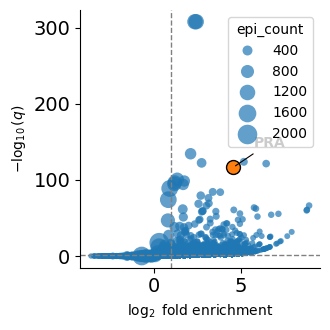

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# thresholds
q_threshold = 0.05
log2fc_threshold = 1   # e.g. 2-fold enrichment

df_plot = df_motifs.copy()

# -log10(q)
df_plot["neglog10_q"] = -np.log10(
    df_plot["q"].clip(lower=np.finfo(float).tiny)
)

# log2FC can be inf when naive_count == 0
df_plot = df_plot[
    np.isfinite(df_plot["log2_fold_enrichment"])
].copy()

##highlighted motif
motif_to_highlight = "PRA"

df_highlight = df_plot[
    df_plot["motif"] == motif_to_highlight
]

fig, ax = plt.subplots(figsize=(3.4, 3.4))

sns.scatterplot(
    data=df_plot,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(15, 200),
    alpha=0.7,
    linewidth=0,
    color="#1F77B4",
    ax=ax,
)

# highlighted motif
sns.scatterplot(
    data=df_highlight,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(100, 100),
    color="tab:orange",
    edgecolor="black",
    linewidth=1,
    legend=False,
    ax=ax,
)

for _, row in df_highlight.iterrows():
    ax.annotate(
        row["motif"],
        xy=(
            row["log2_fold_enrichment"],
            row["neglog10_q"],
        ),
        xytext=(15, 15),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
        ),
    )

# q = 0.05 threshold
ax.axhline(
    -np.log10(q_threshold),
    ls="--",
    lw=1,
    color="grey",
)

# log2 fold-enrichment threshold
ax.axvline(
    log2fc_threshold,
    ls="--",
    lw=1,
    color="grey",
)

ax.set_xlabel(r"$\log_2$ fold enrichment")
ax.set_ylabel(r"$-\log_{10}(q)$")
ax.tick_params(axis='both', labelsize = 14)

sns.despine()
fig.tight_layout()
fig.savefig('./kmer_enrichment/OVA_fc_selection.pdf')
plt.show()

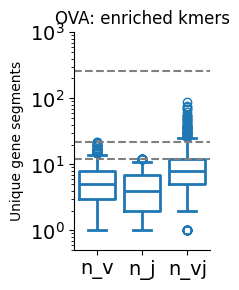

In [13]:
import seaborn as sns

cols = ["n_v", "n_j", "n_vj"]

fig, ax = plt.subplots(figsize=(2.3, 3))

#lower = df_sum[cols].quantile(0.05)
#upper = df_sum[cols].quantile(0.95)

#df_outliers = df_sum[cols].where(
#    (df_sum[cols] < lower) |
#    (df_sum[cols] > upper)
#)

sns.boxplot(
    data=df_motif_summary[cols],
    ax=ax,
    showfliers=True, whis = (5,95),  palette = ['#1F77B4','#1F77B4','#1F77B4'], fill = False, linewidth = 2,
)
#sns.stripplot(
#    data=df_outliers,
#    size=3,
#    color="black",
#    alpha=1,
#    jitter=0.1,
#    ax=ax,
#)

total_v = 22
total_j = 12
total_vj = total_v*total_j

ax.axhline(y=total_v, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_j, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_vj, linestyle="--", color="gray", linewidth=1.5)

ax.set_yscale('log')
ax.set_ylim(0.5, 1000)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel('Unique gene segments')
ax.tick_params(axis='both', labelsize = 14)
ax.set_title('OVA: enriched kmers')


fig.tight_layout()
fig.savefig("./kmer_enrichment/OVA_kmer_v_j.pdf")

In [14]:
df_motif_summary.sort_values(by = 'log2_fold_enrichment', ascending = False).to_excel('./kmer_enrichment/ova_kmer_enrichment.xlsx')

C:\Users\wwspa\TCR_scripts\04_Saturation_manuscript\manuscript_data\cdr3_logo_epitope_baseline_matched_length.py:1428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


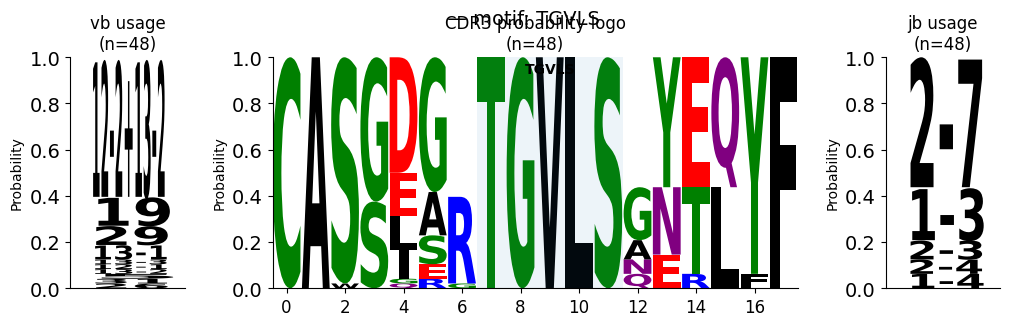

In [15]:
import cdr3_logo_epitope_baseline_matched_length as tlp
#kmer to plot
kmer = 'TGVLS'
#contributing length restriction set to 0
contribut_length = df_epi_motifs.loc[df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer)].cdr3b_aa_len.value_counts()
contribut_length = contribut_length[contribut_length>0].index.tolist()
df_plot = df_epi_motifs.loc[(df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer))&(df_epi_motifs.cdr3b_aa_len.isin(contribut_length))]

fig, result = tlp.plot_cdr3_logo_aligned(
    df=df_plot,
    cdr3_col="cdr3b_aa",
    v_col="vb",
    j_col="jb",
    kmer="TGVLS",
    title="",
    cdr3_logo_type="probability",
    save_path="./kmer_enrichment/OVA_kmer_logoplot_TGVLS.pdf",
)

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\3094099215.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\3094099215.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\3094099215.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated

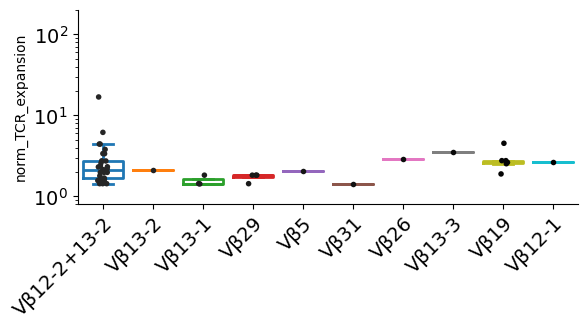

In [16]:
vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.6*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'norm_TCR_expansion', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'norm_TCR_expansion',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_yscale('log')
ax.set_ylim(0.8,200)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
ax.set_xlabel('')
fig.tight_layout()
fig.savefig("./kmer_enrichment/OVA_kmer_clone_size_TGVLS.pdf")

C:\Users\wwspa\TCR_scripts\04_Saturation_manuscript\manuscript_data\cdr3_logo_epitope_baseline_matched_length.py:1428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


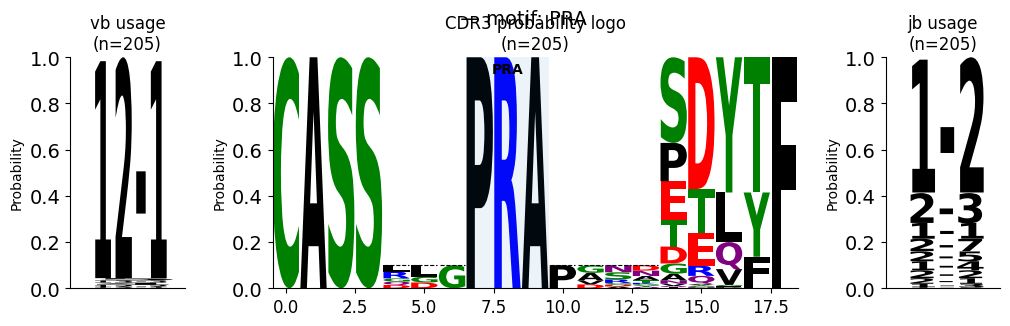

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2163725583.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2163725583.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2163725583.py:27: FutureWarning: 

Setting a gradient palette using color= is depreca

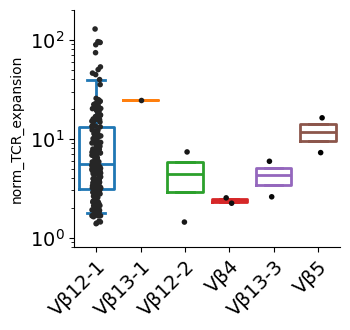

In [17]:
import cdr3_logo_epitope_baseline_matched_length as tlp
#kmer to plot
kmer = 'PRA'
#contributing length restriction set to 0
contribut_length = df_epi_motifs.loc[df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer)].cdr3b_aa_len.value_counts()
contribut_length = contribut_length[contribut_length>0].index.tolist()
df_plot = df_epi_motifs.loc[(df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer))&(df_epi_motifs.cdr3b_aa_len.isin(contribut_length))]

fig, result = tlp.plot_cdr3_logo_aligned(
    df=df_plot,
    cdr3_col="cdr3b_aa",
    v_col="vb",
    j_col="jb",
    kmer="PRA",
    title="",
    cdr3_logo_type="probability",
    save_path="./kmer_enrichment/OVA_kmer_logoplot_PRA.pdf",
)

vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.6*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'norm_TCR_expansion', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'norm_TCR_expansion',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_yscale('log')
ax.set_ylim(0.8,200)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
ax.set_xlabel('')
fig.tight_layout()
fig.savefig("./kmer_enrichment/OVA_kmer_clone_size_PRA.pdf")

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated

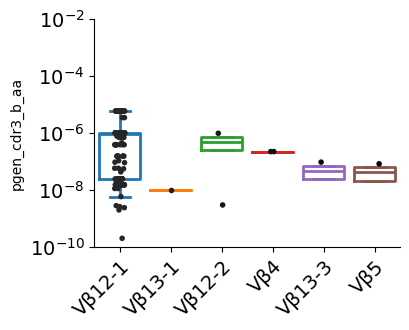

In [18]:
vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.7*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'pgen_cdr3_b_aa', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'pgen_cdr3_b_aa',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_xlabel('')
ax.set_yscale('log')
ax.set_ylim(10**-10,10**-2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
fig.tight_layout()

## GP33

In [19]:
df = df_tcr[df_tcr.annotated_specificity=='GP33'].reset_index(drop = True).copy()
df.tcr_id.nunique()

8399

In [20]:
df_motifs, df_epi_motifs = motif_enrichment_vs_naive(
    df_epi=df,
    df_naive=df_naive_tcr,
    seq_col="cdr3b_aa",
    motif_lengths=(3, 4, 5),
    ntrim=2,
    ctrim=3,
    min_epi_count=3,
    collapse_motifs="shortest",  # "longest" or None
)
#annotate length
df_epi_motifs['cdr3b_aa_len'] = df_epi_motifs['cdr3b_aa'].apply(len)
df_motifs.head(20)#[df_motifs.epi_count>100].head(20)


#annotate significance
df_motifs_sig = df_motifs[
    (df_motifs["q"] < 0.05) &
    (df_motifs["log2_fold_enrichment"] > 1) &
    (df_motifs["epi_count"] >= 10) &
    (df_motifs["naive_count"] >= 3)
].copy()



df_epi_unique = (
    df[
        [
            "cdr3b_aa",
            "vb",
            "jb",
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

df_epi_unique["cdr3b_trimmed"] = (
    df_epi_unique["cdr3b_aa"]
    .apply(lambda x: trim_cdr3(x, ntrim=2, ctrim=3))
)

# make summary of results
rows = []

for motif in df_motifs_sig["motif"]:

    df_m = df_epi_unique[
        df_epi_unique["cdr3b_trimmed"].str.contains(
            motif,
            regex=False,
            na=False,
        )
    ].copy()

    if len(df_m) == 0:
        continue

    df_m["motif"] = motif

    rows.append(df_m)

df_motif_tcr = pd.concat(
    rows,
    ignore_index=True,
)

#annotate vj

df_motif_tcr["trb_vj"] = (
    df_motif_tcr["vb"].astype(str)
    + "_"
    + df_motif_tcr["jb"].astype(str)
)



df_motif_summary = (
    df_motif_tcr
    .groupby("motif")
    .agg(
        n_tcr=("cdr3b_aa", "nunique"),
        n_v=("vb", "nunique"),
        n_j=("jb", "nunique"),
        n_vj=("trb_vj", "nunique"),
    )
    .reset_index()
)

df_motif_summary = df_motif_summary.merge(
    df_motifs_sig[
        [
            "motif",
            "epi_count",
            "naive_count",
            "log2_fold_enrichment",
            "q",
        ]
    ],
    on="motif",
    how="left",
)

Epitope unique CDR3s: 8,399
Naive unique CDR3s:   82,761
Generating epitope motifs...
Generating naive motifs...
Candidate epitope motifs: 7,052


Testing motif enrichment: 100%|███████████████████████████████████████████████| 7052/7052 [00:01<00:00, 3948.88motif/s]


Collapsed motifs (shortest retained): 7,052 -> 4,601
TCRs carrying >=1 retained motif: 8,398 / 8,399


In [21]:
df_motif_summary[df_motif_summary.log2_fold_enrichment>4].sort_values(by = ['n_vj','epi_count'], ascending=[False,False]).head(10)

,motif,n_tcr,n_v,n_j,n_vj,epi_count,naive_count,log2_fold_enrichment,q
30,DAGA,40,5,11,22,202,63,4.981593,2.838268e-149
387,SDWD,28,5,9,21,217,34,5.974750,1.692495e-183
362,SDAGA,33,3,11,18,171,37,5.509061,1.291050e-136
135,DWT,34,6,9,15,258,95,4.742033,4.813021e-183
9,AGAR,12,4,7,13,34,14,4.580770,2.227563e-23
32,DAGAR,10,4,7,12,32,5,5.978734,6.297785e-27
404,SEW,29,2,8,11,85,43,4.283788,1.571578e-54
226,HRDW,14,7,5,11,61,35,4.102116,1.755133e-37
429,SHRDW,13,7,5,11,53,30,4.121691,8.863249e-33
503,SSSWD,15,6,9,11,28,11,4.648585,1.369953e-19


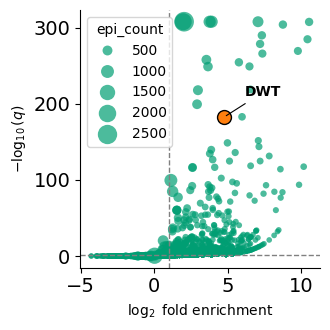

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# thresholds
q_threshold = 0.05
log2fc_threshold = 1   # e.g. 2-fold enrichment

df_plot = df_motifs.copy()

# -log10(q)
df_plot["neglog10_q"] = -np.log10(
    df_plot["q"].clip(lower=np.finfo(float).tiny)
)

# log2FC can be inf when naive_count == 0
df_plot = df_plot[
    np.isfinite(df_plot["log2_fold_enrichment"])
].copy()

##highlighted motif
motif_to_highlight = "DWT"

df_highlight = df_plot[
    df_plot["motif"] == motif_to_highlight
]

fig, ax = plt.subplots(figsize=(3.4, 3.4))

sns.scatterplot(
    data=df_plot,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(15, 200),
    alpha=0.7,
    linewidth=0,
    color="#009E73",
    ax=ax,
)

# highlighted motif
sns.scatterplot(
    data=df_highlight,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(100, 100),
    color="tab:orange",
    edgecolor="black",
    linewidth=1,
    legend=False,
    ax=ax,
)

for _, row in df_highlight.iterrows():
    ax.annotate(
        row["motif"],
        xy=(
            row["log2_fold_enrichment"],
            row["neglog10_q"],
        ),
        xytext=(15, 15),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
        ),
    )

# q = 0.05 threshold
ax.axhline(
    -np.log10(q_threshold),
    ls="--",
    lw=1,
    color="grey",
)

# log2 fold-enrichment threshold
ax.axvline(
    log2fc_threshold,
    ls="--",
    lw=1,
    color="grey",
)

ax.set_xlabel(r"$\log_2$ fold enrichment")
ax.set_ylabel(r"$-\log_{10}(q)$")
ax.tick_params(axis='both', labelsize = 14)

sns.despine()
fig.tight_layout()
fig.savefig('./kmer_enrichment/GP33_fc_selection.pdf')
plt.show()

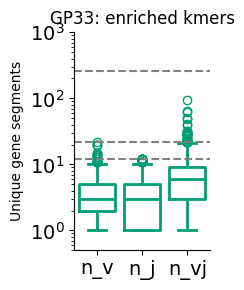

In [23]:
cols = ["n_v", "n_j", "n_vj"]

fig, ax = plt.subplots(figsize=(2.3, 3))

#lower = df_sum[cols].quantile(0.05)
#upper = df_sum[cols].quantile(0.95)

#df_outliers = df_sum[cols].where(
#    (df_sum[cols] < lower) |
#    (df_sum[cols] > upper)
#)

sns.boxplot(
    data=df_motif_summary[cols],
    ax=ax,
    showfliers=True, whis = (5,95),  palette = ['#009E73','#009E73','#009E73'], fill = False, linewidth = 2,
)
#sns.stripplot(
#    data=df_outliers,
#    size=3,
#    color="black",
#    alpha=1,
#    jitter=0.1,
#    ax=ax,
#)

total_v = 22
total_j = 12
total_vj = total_v*total_j

ax.axhline(y=total_v, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_j, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_vj, linestyle="--", color="gray", linewidth=1.5)

ax.set_yscale('log')
ax.set_ylim(0.5, 1000)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel('Unique gene segments')
ax.tick_params(axis='both', labelsize = 14)
ax.set_title('GP33: enriched kmers')


fig.tight_layout()
fig.savefig("./kmer_enrichment/GP33_kmer_v_j.pdf")

In [24]:
df_motif_summary.sort_values(by = 'log2_fold_enrichment', ascending = False).to_excel("./kmer_enrichment/GP33_kmer_enrichment.xlsx")

C:\Users\wwspa\TCR_scripts\04_Saturation_manuscript\manuscript_data\cdr3_logo_epitope_baseline_matched_length.py:1428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


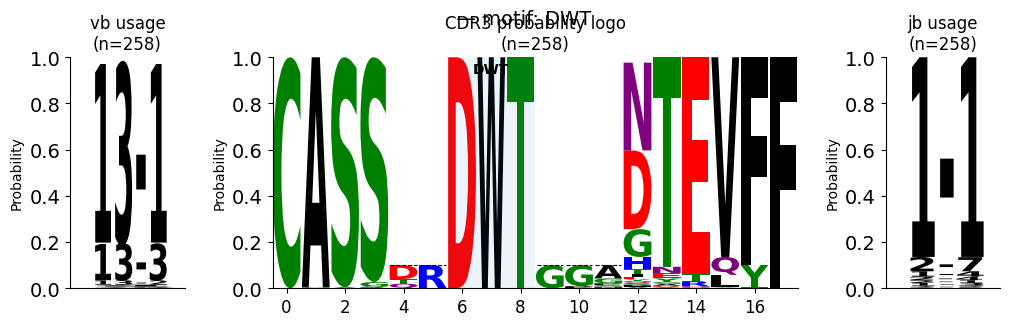

In [25]:
import cdr3_logo_epitope_baseline_matched_length as tlp
#kmer to plot
kmer = 'DWT'
#contributing length restriction set to 0
contribut_length = df_epi_motifs.loc[df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer)].cdr3b_aa_len.value_counts()
contribut_length = contribut_length[contribut_length>0].index.tolist()
df_plot = df_epi_motifs.loc[(df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer))&(df_epi_motifs.cdr3b_aa_len.isin(contribut_length))]

fig, result = tlp.plot_cdr3_logo_aligned(
    df=df_plot,
    cdr3_col="cdr3b_aa",
    v_col="vb",
    j_col="jb",
    kmer="DWT",
    title="",
    cdr3_logo_type="probability",
    save_path="./kmer_enrichment/GP33_kmer_logoplot.pdf",
)

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2198464638.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2198464638.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2198464638.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated

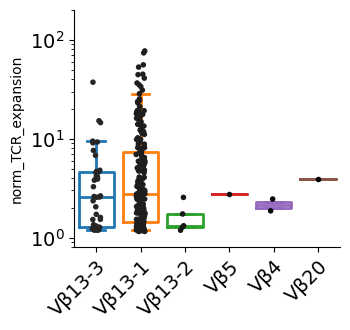

In [26]:
vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.6*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'norm_TCR_expansion', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'norm_TCR_expansion',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_yscale('log')
ax.set_ylim(0.8,200)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
ax.set_xlabel('')

fig.tight_layout()

fig.savefig("./kmer_enrichment/GP33_kmer_clone_size.pdf")

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\4246638646.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated

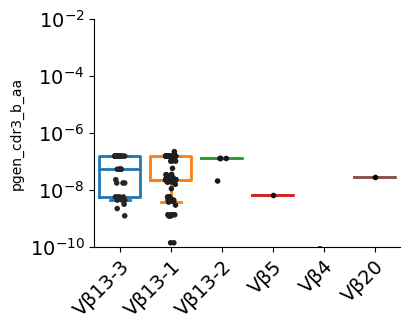

In [27]:
vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.7*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'pgen_cdr3_b_aa', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'pgen_cdr3_b_aa',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_xlabel('')
ax.set_yscale('log')
ax.set_ylim(10**-10,10**-2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
fig.tight_layout()

## M45

In [28]:
df = df_tcr[df_tcr.annotated_specificity=='M45'].reset_index(drop = True).copy()
df.tcr_id.nunique()

4228

In [29]:
df_motifs, df_epi_motifs = motif_enrichment_vs_naive(
    df_epi=df,
    df_naive=df_naive_tcr,
    seq_col="cdr3b_aa",
    motif_lengths=(3, 4, 5),
    ntrim=2,
    ctrim=3,
    min_epi_count=3,
    collapse_motifs="shortest",  # "longest" or None
)
#annotate length
df_epi_motifs['cdr3b_aa_len'] = df_epi_motifs['cdr3b_aa'].apply(len)
#df_motifs.head(20)#[df_motifs.epi_count>100].head(20)


df_motifs_sig = df_motifs[
    (df_motifs["q"] < 0.05) &
    (df_motifs["log2_fold_enrichment"] > 1) &
    (df_motifs["epi_count"] >= 10) &
    (df_motifs["naive_count"] >= 3)
].copy()



df_epi_unique = (
    df[
        [
            "cdr3b_aa",
            "vb",
            "jb",
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

df_epi_unique["cdr3b_trimmed"] = (
    df_epi_unique["cdr3b_aa"]
    .apply(lambda x: trim_cdr3(x, ntrim=2, ctrim=3))
)

rows = []

for motif in df_motifs_sig["motif"]:

    df_m = df_epi_unique[
        df_epi_unique["cdr3b_trimmed"].str.contains(
            motif,
            regex=False,
            na=False,
        )
    ].copy()

    if len(df_m) == 0:
        continue

    df_m["motif"] = motif

    rows.append(df_m)

df_motif_tcr = pd.concat(
    rows,
    ignore_index=True,
)


df_motif_tcr["trb_vj"] = (
    df_motif_tcr["vb"].astype(str)
    + "_"
    + df_motif_tcr["jb"].astype(str)
)

df_motif_summary = (
    df_motif_tcr
    .groupby("motif")
    .agg(
        n_tcr=("cdr3b_aa", "nunique"),
        n_v=("vb", "nunique"),
        n_j=("jb", "nunique"),
        n_vj=("trb_vj", "nunique"),
    )
    .reset_index()
)

df_motif_summary = df_motif_summary.merge(
    df_motifs_sig[
        [
            "motif",
            "epi_count",
            "naive_count",
            "log2_fold_enrichment",
            "q",
        ]
    ],
    on="motif",
    how="left",
)

Epitope unique CDR3s: 4,228
Naive unique CDR3s:   82,761
Generating epitope motifs...
Generating naive motifs...
Candidate epitope motifs: 3,160


Testing motif enrichment: 100%|███████████████████████████████████████████████| 3160/3160 [00:00<00:00, 4075.08motif/s]


Collapsed motifs (shortest retained): 3,160 -> 2,043
TCRs carrying >=1 retained motif: 4,228 / 4,228


In [30]:
df_motif_summary[df_motif_summary.log2_fold_enrichment>4].sort_values(by = ['n_vj','epi_count'], ascending=[False,False]).head(10)

,motif,n_tcr,n_v,n_j,n_vj,epi_count,naive_count,log2_fold_enrichment,q
199,RGD,113,6,11,26,963,680,4.792905,0.000000e+00
323,SYR,45,4,12,21,221,268,4.012717,3.278494e-152
49,GDN,76,8,7,19,562,574,4.260423,0.000000e+00
238,SFR,74,4,12,17,533,489,4.415205,0.000000e+00
42,FRG,44,3,11,14,448,187,5.551364,0.000000e+00
239,SFRG,41,3,11,14,444,156,5.799917,0.000000e+00
354,YRG,37,3,10,14,223,254,4.103119,1.268650e-157
355,YRGD,30,3,10,14,216,15,8.138901,9.919427e-262
43,FRGD,29,2,11,13,427,14,9.221641,0.000000e+00
240,SFRGD,26,2,11,13,423,10,9.693490,0.000000e+00


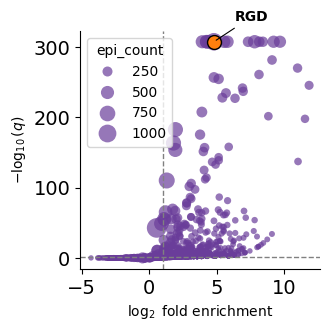

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# thresholds
q_threshold = 0.05
log2fc_threshold = 1   # e.g. 2-fold enrichment

df_plot = df_motifs.copy()

# -log10(q)
df_plot["neglog10_q"] = -np.log10(
    df_plot["q"].clip(lower=np.finfo(float).tiny)
)

# log2FC can be inf when naive_count == 0
df_plot = df_plot[
    np.isfinite(df_plot["log2_fold_enrichment"])
].copy()

##highlighted motif
motif_to_highlight = "RGD"

df_highlight = df_plot[
    df_plot["motif"] == motif_to_highlight
]

fig, ax = plt.subplots(figsize=(3.4, 3.4))

sns.scatterplot(
    data=df_plot,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(15, 200),
    alpha=0.7,
    linewidth=0,
    color="#6A3D9A",
    ax=ax,
)

# highlighted motif
sns.scatterplot(
    data=df_highlight,
    x="log2_fold_enrichment",
    y="neglog10_q",
    size="epi_count",
    sizes=(100, 100),
    color="tab:orange",
    edgecolor="black",
    linewidth=1,
    legend=False,
    ax=ax,
)

for _, row in df_highlight.iterrows():
    ax.annotate(
        row["motif"],
        xy=(
            row["log2_fold_enrichment"],
            row["neglog10_q"],
        ),
        xytext=(15, 15),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            lw=0.8,
        ),
    )

# q = 0.05 threshold
ax.axhline(
    -np.log10(q_threshold),
    ls="--",
    lw=1,
    color="grey",
)

# log2 fold-enrichment threshold
ax.axvline(
    log2fc_threshold,
    ls="--",
    lw=1,
    color="grey",
)

ax.set_xlabel(r"$\log_2$ fold enrichment")
ax.set_ylabel(r"$-\log_{10}(q)$")
ax.tick_params(axis='both', labelsize = 14)

sns.despine()
fig.tight_layout()
fig.savefig('./kmer_enrichment/M45_fc_selection.pdf')
plt.show()

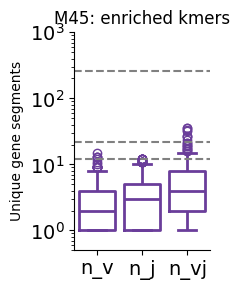

In [32]:
cols = ["n_v", "n_j", "n_vj"]

fig, ax = plt.subplots(figsize=(2.3, 3))

#lower = df_sum[cols].quantile(0.05)
#upper = df_sum[cols].quantile(0.95)

#df_outliers = df_sum[cols].where(
#    (df_sum[cols] < lower) |
#    (df_sum[cols] > upper)
#)

sns.boxplot(
    data=df_motif_summary[cols],
    ax=ax,
    showfliers=True, whis = (5,95),  palette = ['#6A3D9A','#6A3D9A','#6A3D9A'], fill = False, linewidth = 2,
)
#sns.stripplot(
#    data=df_outliers,
#    size=3,
#    color="black",
#    alpha=1,
#    jitter=0.1,
#    ax=ax,
#)

total_v = 22
total_j = 12
total_vj = total_v*total_j

ax.axhline(y=total_v, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_j, linestyle="--", color="gray", linewidth=1.5)
ax.axhline(y=total_vj, linestyle="--", color="gray", linewidth=1.5)

ax.set_yscale('log')
ax.set_ylim(0.5, 1000)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel('Unique gene segments')
ax.tick_params(axis='both', labelsize = 14)
ax.set_title('M45: enriched kmers')


fig.tight_layout()
fig.savefig("./kmer_enrichment/M45_kmer_v_j.pdf")

In [33]:
df_motif_summary.sort_values(by='log2_fold_enrichment', ascending=False).to_excel("./kmer_enrichment/M45_kmer_enrichment.xlsx")

C:\Users\wwspa\TCR_scripts\04_Saturation_manuscript\manuscript_data\cdr3_logo_epitope_baseline_matched_length.py:1428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


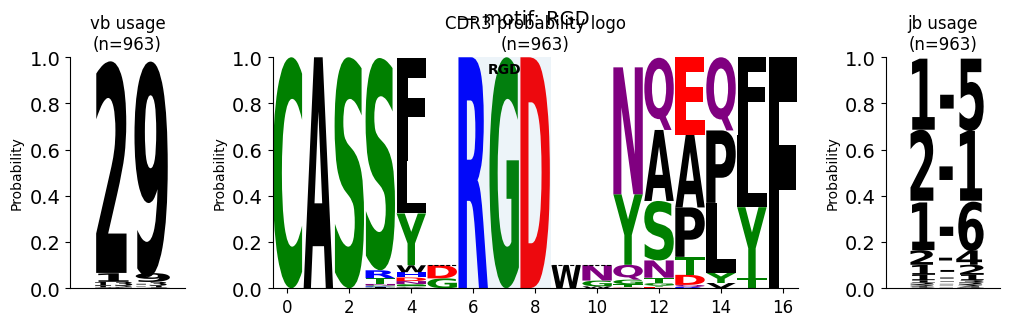

In [34]:
kmer = 'RGD'

#contributing length restriction for logo set to 0
contribut_length = df_epi_motifs.loc[df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer)].cdr3b_aa_len.value_counts()
contribut_length = contribut_length[contribut_length>0].index.tolist()
df_plot = df_epi_motifs.loc[(df_epi_motifs.cdr3b_aa_trimmed.str.contains(kmer))&(df_epi_motifs.cdr3b_aa_len.isin(contribut_length))]

fig, result = tlp.plot_cdr3_logo_aligned(
    df=df_plot,
    cdr3_col="cdr3b_aa",
    v_col="vb",
    j_col="jb",
    kmer="RGD",
    title="",
    cdr3_logo_type="probability",
    save_path=("./kmer_enrichment/M45_kmer_logoplot.pdf")
)

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2203286768.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2203286768.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
C:\Users\wwspa\AppData\Local\Temp\ipykernel_7224\2203286768.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated

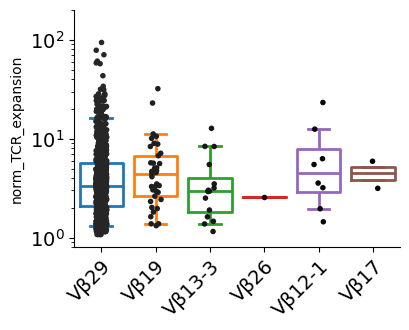

In [35]:
vb_len = len(df_plot.vb.unique())

fig, ax = plt.subplots(figsize=(0.7*vb_len, 3.4))

df_plot["vb"] = df_plot["vb"].str.replace("TRBV","Vβ",regex=False)
df_plot["vb"] = df_plot["vb"].str.replace("Vβ12-2+Vβ13-2","Vβ12-2+13-2",regex=False)
    
sns.stripplot(data = df_plot, y = 'norm_TCR_expansion', x = 'vb', hue = 'vb', ax=ax, legend =False, color = 'black', size = 4)
sns.boxplot(
    data=df_plot,
    ax=ax,
    x = 'vb', hue = 'vb',
    y = 'norm_TCR_expansion',legend =False,
    showfliers=False, whis = (5,95), fill = False, linewidth = 2,
)
ax.set_xlabel('')
ax.set_yscale('log')
ax.set_ylim(0.8,200)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14, rotation_mode='anchor')
fig.tight_layout()

fig.savefig("./kmer_enrichment/M45_kmer_clone_size.pdf")